In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import duckdb
#Connexion à la base de données DuckDB
con = duckdb.connect(database='lactate.duckdb', read_only=False)
print("Connexion à la base de données réussie !")

Connexion à la base de données réussie !


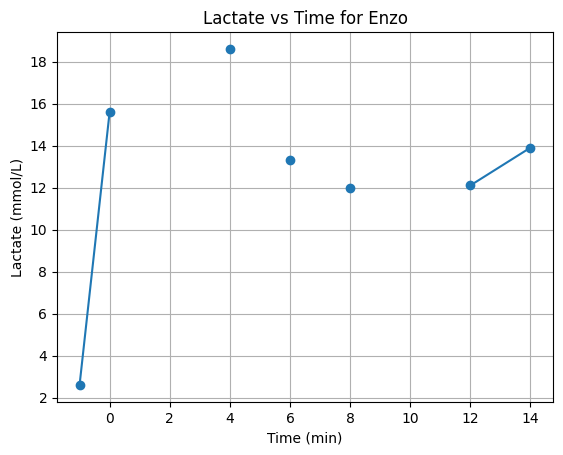

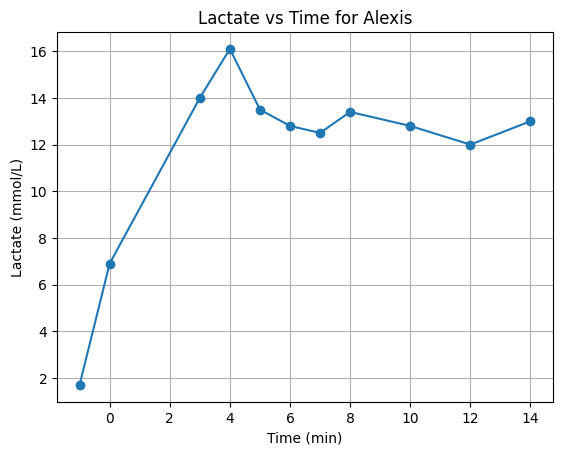

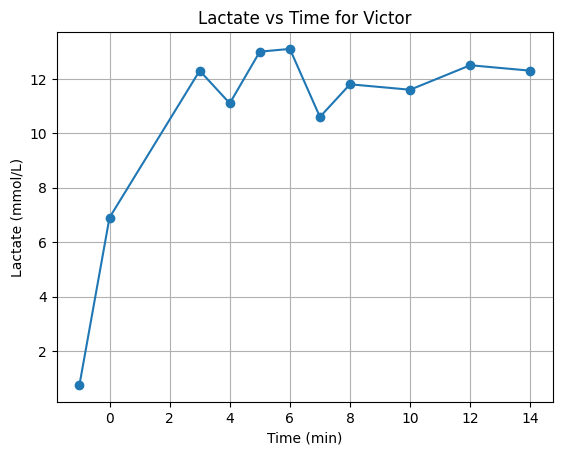

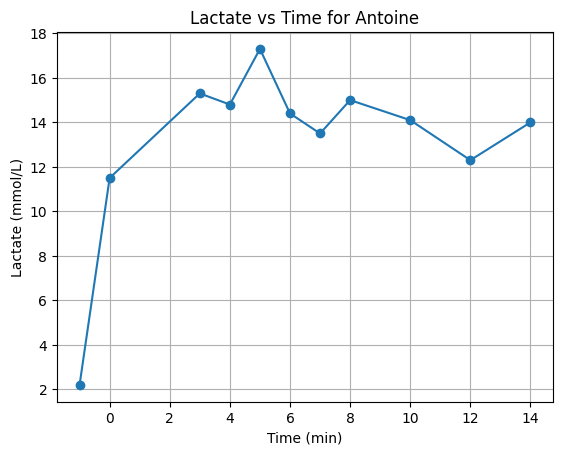

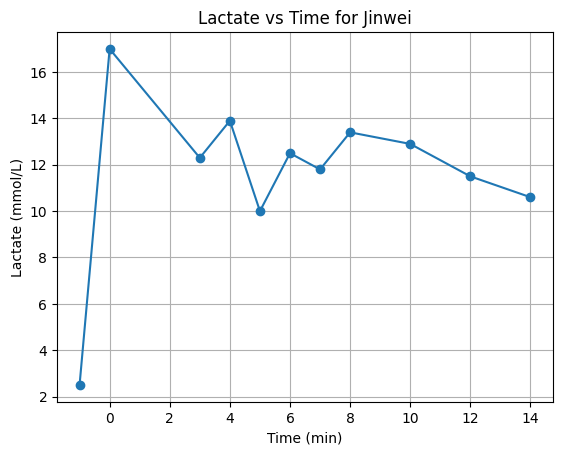

In [3]:
#Tracer pour chaque sujet la courbe de lactate en fonction du temps
#Un graphique par sujet 

query = "SELECT subject_name, time_min, lactate_mmol_l FROM lactate_data"
df = con.execute(query).fetchdf()
subjects = df['subject_name'].unique()
for subject in subjects:
    subject_data = df[df['subject_name'] == subject]
    plt.figure()
    plt.plot(subject_data['time_min'], subject_data['lactate_mmol_l'], marker='o')
    plt.title(f'Lactate vs Time for {subject}')
    plt.xlabel('Time (min)')
    plt.ylabel('Lactate (mmol/L)')
    plt.grid()
    plt.show()

📌 Sujet : Alexis
   ➤ Valeur minimale de SmO2 dans la 1ère minute : 60.68 %
   ➤ Temps depuis le début jusqu'à ce point     : 30.24 s



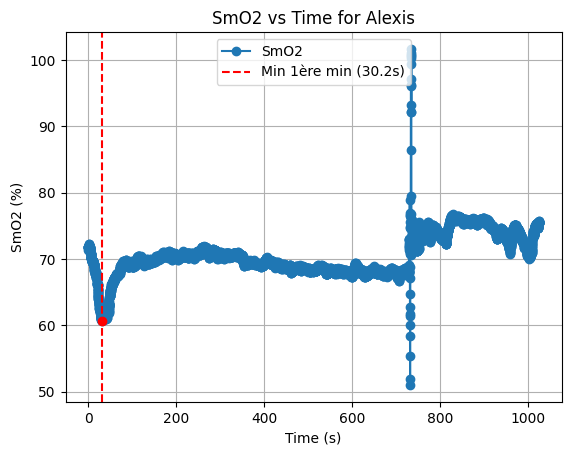

📌 Sujet : Antoine
   ➤ Valeur minimale de SmO2 dans la 1ère minute : 61.61 %
   ➤ Temps depuis le début jusqu'à ce point     : 55.80 s



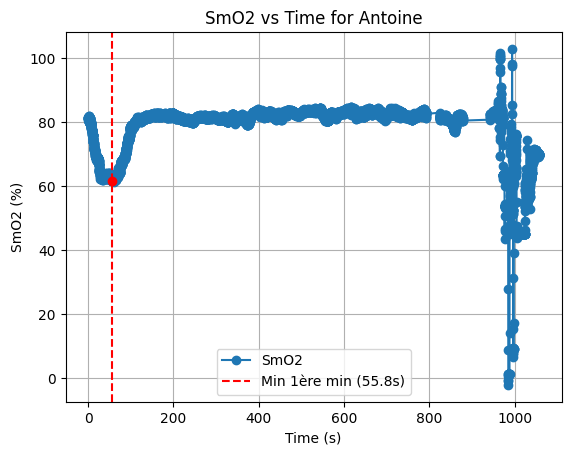

📌 Sujet : Enzo
   ➤ Valeur minimale de SmO2 dans la 1ère minute : 56.98 %
   ➤ Temps depuis le début jusqu'à ce point     : 38.47 s



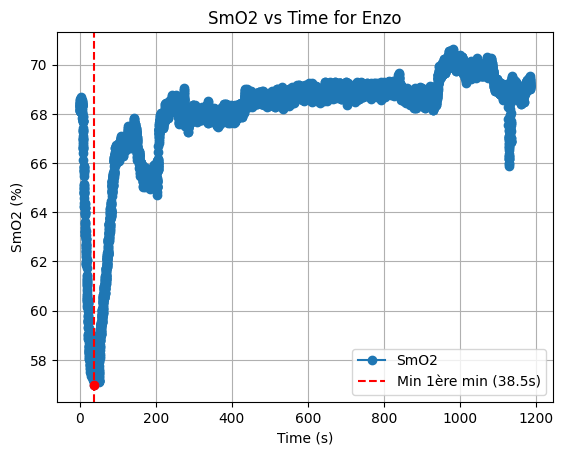

📌 Sujet : Jinwei
   ➤ Valeur minimale de SmO2 dans la 1ère minute : 61.67 %
   ➤ Temps depuis le début jusqu'à ce point     : 28.80 s



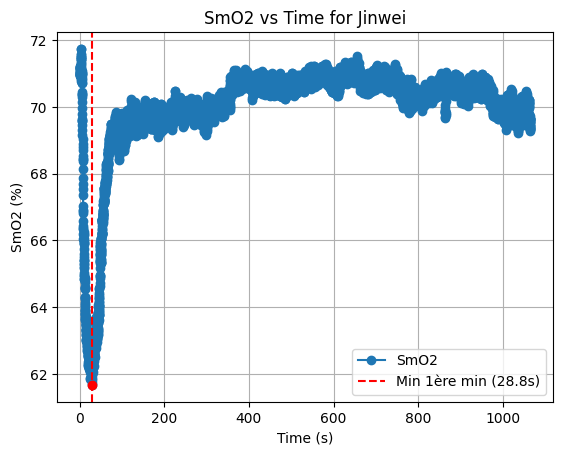

📌 Sujet : Victor
   ➤ Valeur minimale de SmO2 dans la 1ère minute : 60.68 %
   ➤ Temps depuis le début jusqu'à ce point     : 30.24 s



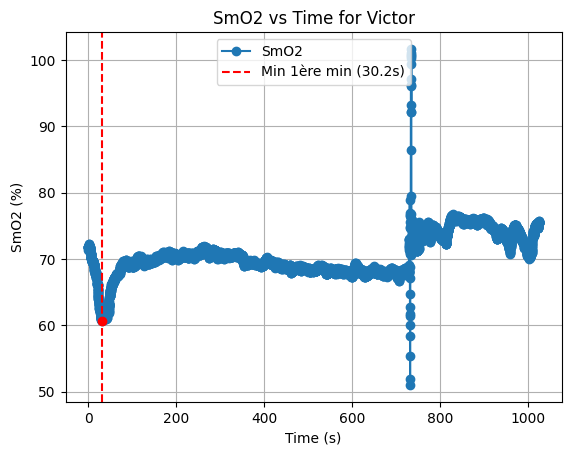

In [4]:
query = "SELECT subject_name, timestamp_s, smo2, hbdiff FROM sensor_timeseries"
df = con.execute(query).fetchdf()

subjects = df['subject_name'].unique()

for subject in subjects:
    subject_data = df[df['subject_name'] == subject].copy()
    
    # ⏱️ Récupérer le temps de début
    t_start = subject_data['timestamp_s'].min()
    
    # 🔍 Filtrer la première minute (60 secondes après le début)
    first_minute = subject_data[subject_data['timestamp_s'] <= t_start + 60]
    
    # 📉 Trouver la première valeur minimale dans la première minute
    min_smo2_value = first_minute['smo2'].min()
    first_min_point = first_minute[first_minute['smo2'] == min_smo2_value].iloc[0]
    
    # ⏱️ Temps écoulé depuis le début
    t_min_point = first_min_point['timestamp_s']
    elapsed_time = t_min_point - t_start
    
    print(f"📌 Sujet : {subject}")
    print(f"   ➤ Valeur minimale de SmO2 dans la 1ère minute : {min_smo2_value:.2f} %")
    print(f"   ➤ Temps depuis le début jusqu'à ce point     : {elapsed_time:.2f} s\n")
    
    # 📊 Tracé de la courbe
    plt.figure()
    plt.plot(subject_data['timestamp_s'], subject_data['smo2'], marker='o', label='SmO2')
    
    # 🔴 Marquer le point minimal
    plt.axvline(x=t_min_point, color='red', linestyle='--', label=f'Min 1ère min ({elapsed_time:.1f}s)')
    plt.scatter(t_min_point, min_smo2_value, color='red', zorder=5)
    
    plt.title(f'SmO2 vs Time for {subject}')
    plt.xlabel('Time (s)')
    plt.ylabel('SmO2 (%)')
    plt.legend()
    plt.grid()
    plt.show()


Sujet : Alexis
   ➤ SmO2  : 8396 points | 14.00 min
   ➤ Lactate : 11 points | temps : [-1.  0.  3.  4.  5.  6.  7.  8. 10. 12. 14.]

Sujet : Antoine
   ➤ SmO2  : 8016 points | 14.00 min
   ➤ Lactate : 11 points | temps : [-1.  0.  3.  4.  5.  6.  7.  8. 10. 12. 14.]

Sujet : Enzo
   ➤ SmO2  : 8400 points | 14.00 min
   ➤ Lactate : 11 points | temps : [-1.  0.  3.  4.  5.  6.  7.  8. 10. 12. 14.]

Sujet : Jinwei
   ➤ SmO2  : 8401 points | 14.00 min
   ➤ Lactate : 11 points | temps : [-1.  0.  3.  4.  5.  6.  7.  8. 10. 12. 14.]

Sujet : Victor
   ➤ SmO2  : 8396 points | 14.00 min
   ➤ Lactate : 11 points | temps : [-1.  0.  3.  4.  5.  6.  7.  8. 10. 12. 14.]



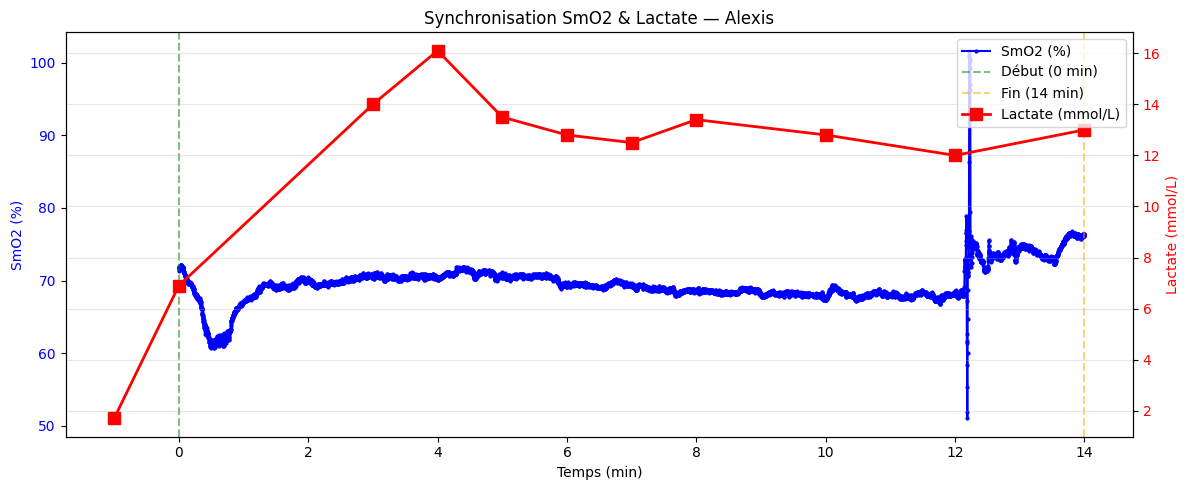

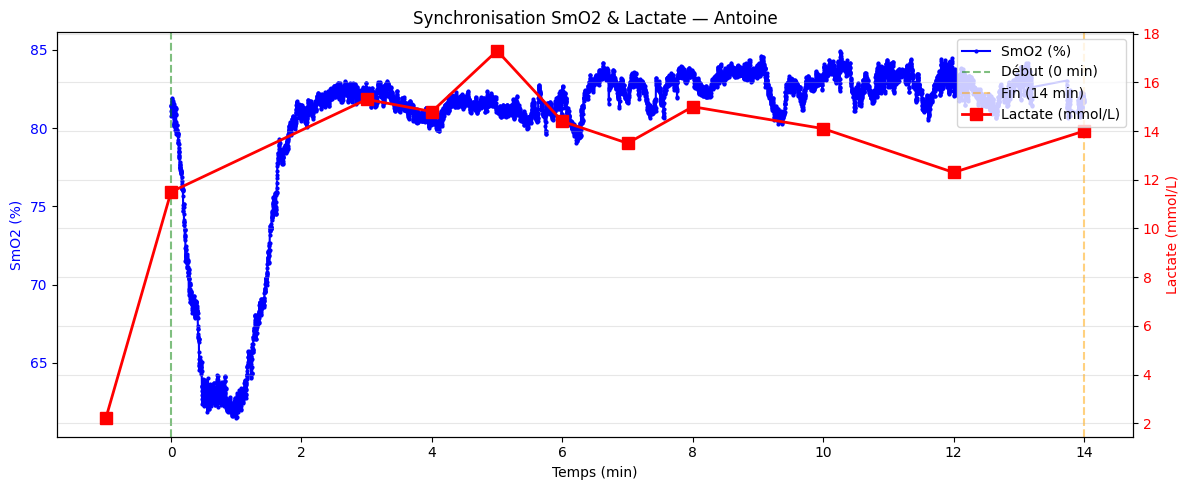

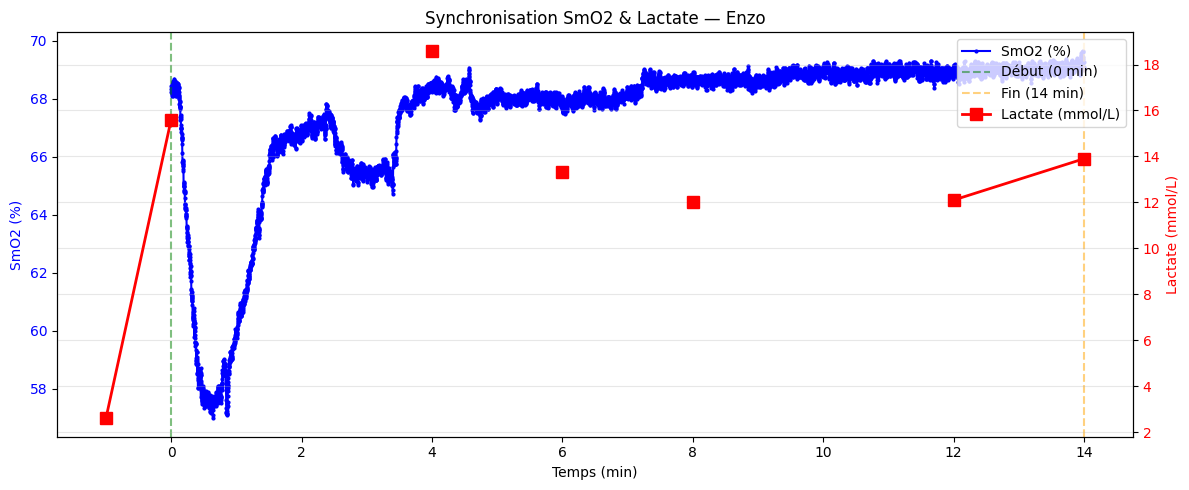

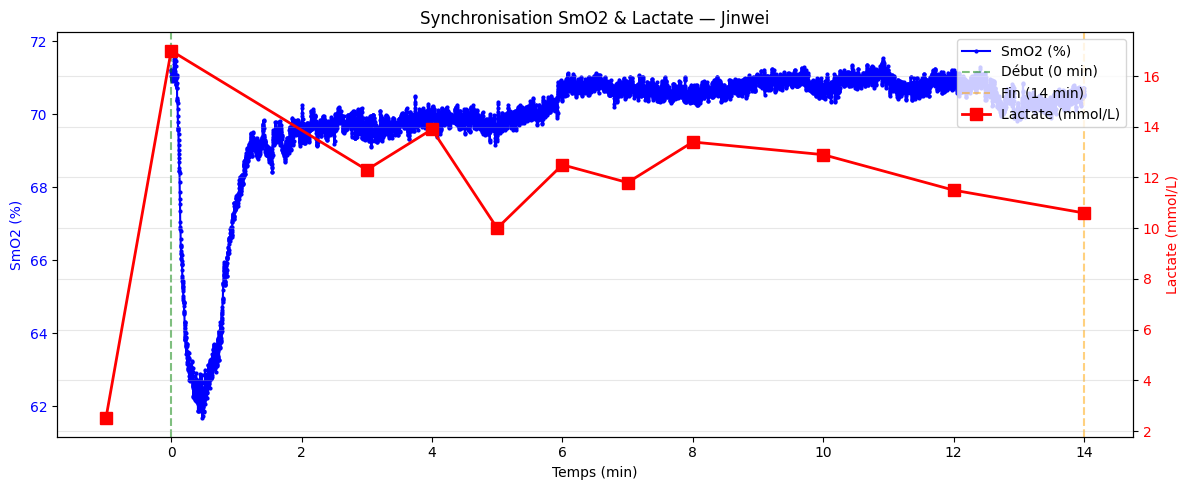

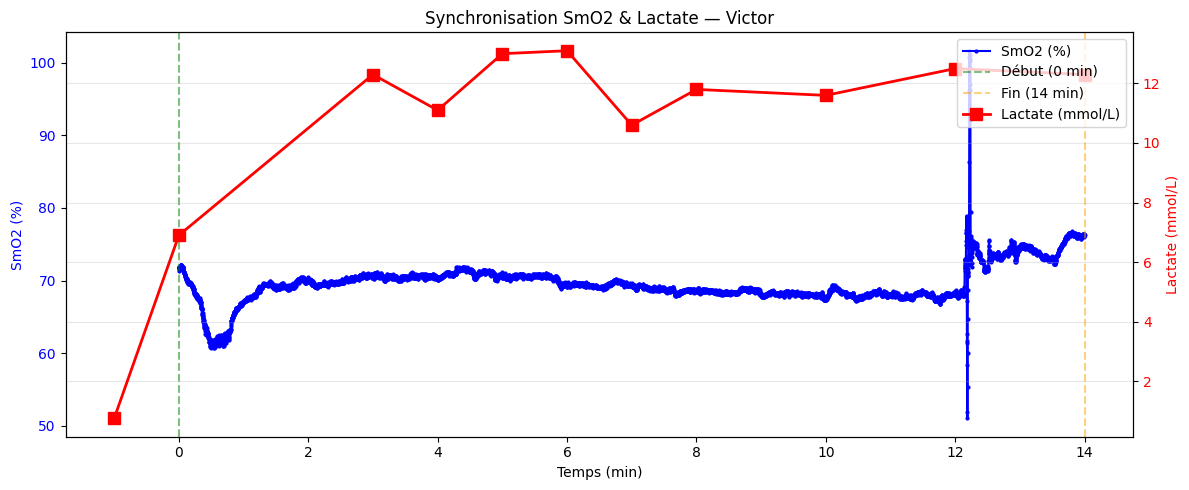

In [8]:
# Données de saturation (SmO2)
query = "SELECT subject_name, timestamp_s, smo2, hbdiff FROM sensor_timeseries"
df_smo2 = con.execute(query).fetchdf()

# Données de lactate (à adapter selon ta table)
query_lac = "SELECT subject_name, time_min, lactate_mmol_l FROM lactate_data"
df_lactate = con.execute(query_lac).fetchdf()

# ─────────────────────────────────────────────
# Synchronisation : 0 min lactate = début SmO2
# ─────────────────────────────────────────────

synced_data = []

for subject in df_smo2['subject_name'].unique():
    
    # --- Données SmO2 du sujet ---
    smo2_subj = df_smo2[df_smo2['subject_name'] == subject].copy()
    smo2_subj = smo2_subj.sort_values('timestamp_s').reset_index(drop=True)
    
    # Temps relatif depuis le début (en secondes)
    t_start = smo2_subj['timestamp_s'].min()
    smo2_subj['time_relative_s'] = smo2_subj['timestamp_s'] - t_start
    smo2_subj['time_relative_min'] = smo2_subj['time_relative_s'] / 60
    
    # Filtrer jusqu'à 14 minutes
    smo2_subj = smo2_subj[smo2_subj['time_relative_min'] <= 14]
    
    # --- Données lactate du sujet ---
    lac_subj = df_lactate[df_lactate['subject_name'] == subject].copy()
    lac_subj = lac_subj.sort_values('time_min').reset_index(drop=True)
    
    # Filtrer jusqu'à 14 minutes
    lac_subj = lac_subj[lac_subj['time_min'] <= 14]
    
    print(f"Sujet : {subject}")
    print(f"   ➤ SmO2  : {len(smo2_subj)} points | {smo2_subj['time_relative_min'].max():.2f} min")
    print(f"   ➤ Lactate : {len(lac_subj)} points | temps : {lac_subj['time_min'].values}\n")
    
    synced_data.append({
        'subject': subject,
        'smo2': smo2_subj,
        'lactate': lac_subj
    })

# ─────────────────────────────────────────────
# Visualisation de la synchronisation
# ─────────────────────────────────────────────

for entry in synced_data:
    subject = entry['subject']
    smo2    = entry['smo2']
    lactate = entry['lactate']
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    
    # SmO2
    ax1.plot(smo2['time_relative_min'], smo2['smo2'], 
             color='blue', marker='o', markersize=2, label='SmO2 (%)')
    ax1.set_xlabel('Temps (min)')
    ax1.set_ylabel('SmO2 (%)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Lactate (axe secondaire)
    ax2 = ax1.twinx()
    ax2.plot(lactate['time_min'], lactate['lactate_mmol_l'], 
             color='red', marker='s', markersize=8, linewidth=2, label='Lactate (mmol/L)')
    ax2.set_ylabel('Lactate (mmol/L)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Ligne de référence à 0 et 14 min
    ax1.axvline(x=0,  color='green', linestyle='--', alpha=0.5, label='Début (0 min)')
    ax1.axvline(x=14, color='orange', linestyle='--', alpha=0.5, label='Fin (14 min)')
    
    plt.title(f'Synchronisation SmO2 & Lactate — {subject}')
    fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# ─────────────────────────────────────────────
# Extraction des features SmO2
# Pour chaque point de mesure lactate, on extrait
# des features SmO2 dans une fenêtre temporelle
# ─────────────────────────────────────────────

from scipy import stats
from scipy.signal import find_peaks

def extract_smo2_features(smo2_window):
    """
    Extrait les features d'une fenêtre de signal SmO2
    """
    smo2 = smo2_window['smo2'].values
    time = smo2_window['time_relative_min'].values
    
    if len(smo2) < 2:
        return None
    
    features = {}
    
    # ─────────────────────────
    # Features statistiques
    # ─────────────────────────
    features['mean']     = np.mean(smo2)
    features['std']      = np.std(smo2)
    features['min']      = np.min(smo2)
    features['max']      = np.max(smo2)
    features['range']    = np.max(smo2) - np.min(smo2)
    features['median']   = np.median(smo2)
    features['q25']      = np.percentile(smo2, 25)
    features['q75']      = np.percentile(smo2, 75)
    features['iqr']      = features['q75'] - features['q25']
    features['skewness'] = stats.skew(smo2)
    features['kurtosis'] = stats.kurtosis(smo2)
    
    # ─────────────────────────
    # Features de tendance
    # ─────────────────────────
    # Pente linéaire (régression)
    if len(time) > 1:
        slope, intercept, r, p, se = stats.linregress(time, smo2)
        features['slope']     = slope       # Vitesse de chute/montée
        features['r_squared'] = r**2        # Qualité de la tendance linéaire
    
    # Variation totale (début → fin de fenêtre)
    features['delta_total']   = smo2[-1] - smo2[0]
    
    # Variation relative
    features['delta_relative'] = (smo2[-1] - smo2[0]) / (smo2[0] + 1e-6) * 100
    
    # ─────────────────────────
    # Features dynamiques
    # ─────────────────────────
    # Vitesse moyenne de changement
    diff = np.diff(smo2)
    features['mean_deriv']    = np.mean(diff)
    features['std_deriv']     = np.std(diff)
    features['max_deriv']     = np.max(np.abs(diff))
    
    # Energie du signal
    features['energy']        = np.sum(smo2**2)
    
    # ─────────────────────────
    # Features temporelles
    # ─────────────────────────
    # Temps pour atteindre le minimum
    idx_min = np.argmin(smo2)
    features['time_to_min']   = time[idx_min]
    
    # Valeur au début de la fenêtre
    features['smo2_start']    = smo2[0]
    
    # Valeur à la fin de la fenêtre
    features['smo2_end']      = smo2[-1]
    
    # Durée de la fenêtre
    features['window_duration'] = time[-1] - time[0]
    
    return features

# ─────────────────────────────────────────────
# Application sur chaque sujet & point lactate
# ─────────────────────────────────────────────

all_features = []

for entry in synced_data:
    subject = entry['subject']
    smo2    = entry['smo2']
    lactate = entry['lactate']
    
    print(f"\n📌 Sujet : {subject}")
    
    for _, lac_row in lactate.iterrows():
        t_lac     = lac_row['time_min']
        lac_value = lac_row['lactate_mmol_l']
        
        # ── Fenêtre SmO2 : du début jusqu'au point lactate ──
        window = smo2[smo2['time_relative_min'] <= t_lac].copy()
        
        if len(window) < 5:
            print(f"   ⚠️  Pas assez de points pour t={t_lac} min")
            continue
        
        # Extraction des features
        feats = extract_smo2_features(window)
        
        if feats is not None:
            feats['subject']   = subject
            feats['time_min']  = t_lac
            feats['lactate']   = lac_value   # 🎯 Variable cible
            all_features.append(feats)
            
            print(f"   ✅ t={t_lac:5.1f} min | Lactate={lac_value:.2f} | "
                  f"SmO2_mean={feats['mean']:.1f} | slope={feats['slope']:.3f}")

# ─────────────────────────────────────────────
# DataFrame final
# ─────────────────────────────────────────────
df_features = pd.DataFrame(all_features)
print(f"\n📊 Dataset final : {df_features.shape[0]} lignes x {df_features.shape[1]} colonnes")
print(df_features.head())



📌 Sujet : Alexis
   ⚠️  Pas assez de points pour t=-1.0 min
   ⚠️  Pas assez de points pour t=0.0 min
   ✅ t=  3.0 min | Lactate=14.00 | SmO2_mean=68.2 | slope=1.836
   ✅ t=  4.0 min | Lactate=16.10 | SmO2_mean=68.8 | slope=1.435
   ✅ t=  5.0 min | Lactate=13.50 | SmO2_mean=69.2 | slope=1.165
   ✅ t=  6.0 min | Lactate=12.80 | SmO2_mean=69.4 | slope=0.833
   ✅ t=  7.0 min | Lactate=12.50 | SmO2_mean=69.4 | slope=0.528
   ✅ t=  8.0 min | Lactate=13.40 | SmO2_mean=69.3 | slope=0.299
   ✅ t= 10.0 min | Lactate=12.80 | SmO2_mean=69.1 | slope=0.052
   ✅ t= 12.0 min | Lactate=12.00 | SmO2_mean=69.0 | slope=-0.047
   ✅ t= 14.0 min | Lactate=13.00 | SmO2_mean=69.6 | slope=0.231

📌 Sujet : Antoine
   ⚠️  Pas assez de points pour t=-1.0 min
   ⚠️  Pas assez de points pour t=0.0 min
   ✅ t=  3.0 min | Lactate=15.30 | SmO2_mean=74.0 | slope=6.463
   ✅ t=  4.0 min | Lactate=14.80 | SmO2_mean=75.8 | slope=4.827
   ✅ t=  5.0 min | Lactate=17.30 | SmO2_mean=77.0 | slope=3.551
   ✅ t=  6.0 min | Lacta

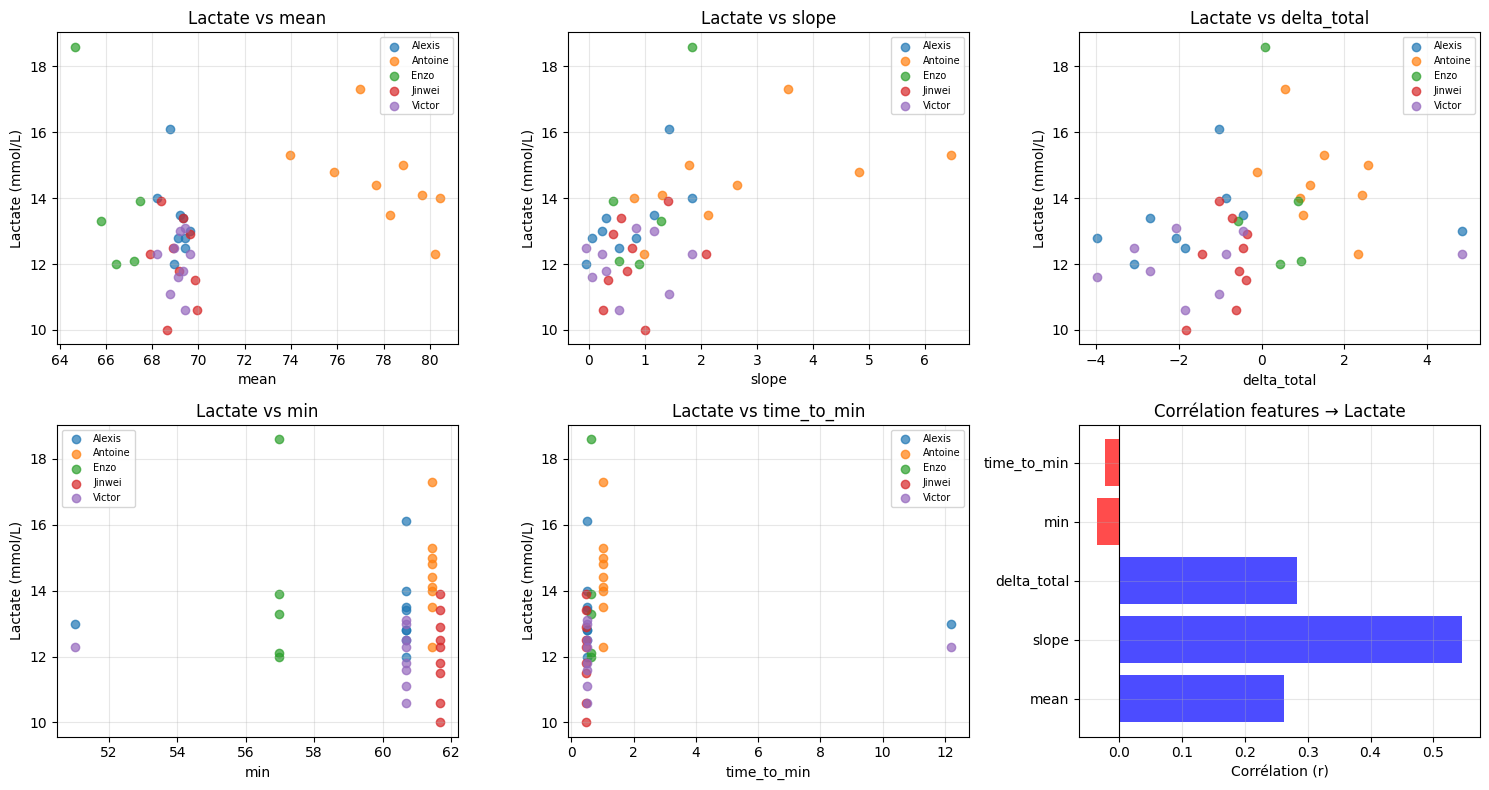

In [14]:
key_features = ['mean', 'slope', 'delta_total', 'min', 'time_to_min']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for subject in df_features['subject'].unique():
        subj_data = df_features[df_features['subject'] == subject]
        ax.scatter(subj_data[feat], subj_data['lactate'], label=subject, alpha=0.7)
    
    ax.set_xlabel(feat)
    ax.set_ylabel('Lactate (mmol/L)')
    ax.set_title(f'Lactate vs {feat}')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Matrice de corrélation
ax = axes[-1]
numeric_feats = df_features[key_features + ['lactate']].corr()['lactate'].drop('lactate')
colors = ['red' if v < 0 else 'blue' for v in numeric_feats.values]
ax.barh(numeric_feats.index, numeric_feats.values, color=colors, alpha=0.7)
ax.set_title('Corrélation features → Lactate')
ax.set_xlabel('Corrélation (r)')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

🗑️  Features supprimées (11) : ['range', 'median', 'q25', 'q75', 'slope', 'delta_relative', 'std_deriv', 'time_to_min', 'smo2_start', 'smo2_end', 'window_duration']
✅  Features conservées (12) : ['mean', 'std', 'min', 'max', 'iqr', 'skewness', 'kurtosis', 'r_squared', 'delta_total', 'mean_deriv', 'max_deriv', 'energy']

📊 X shape final : (45, 14)
🎯 y shape       : (45,)
👥 Sujets        : ['Alexis' 'Antoine' 'Enzo' 'Jinwei' 'Victor']

Modèle                        RMSE      MAE       R²
───────────────────────────────────────────────────────
Linear Regression           19.452   12.373 -145.633
Ridge                        1.564    1.114    0.052
Lasso                        2.643    1.626   -1.707
ElasticNet                   2.858    1.764   -2.166
SVR                          1.793    1.410   -0.245
KNN                          1.651    1.273   -0.056
Random Forest                1.670    1.253   -0.081
Gradient Boosting            1.698    1.180   -0.118

🏆 Meilleur modèle : Ridge
  

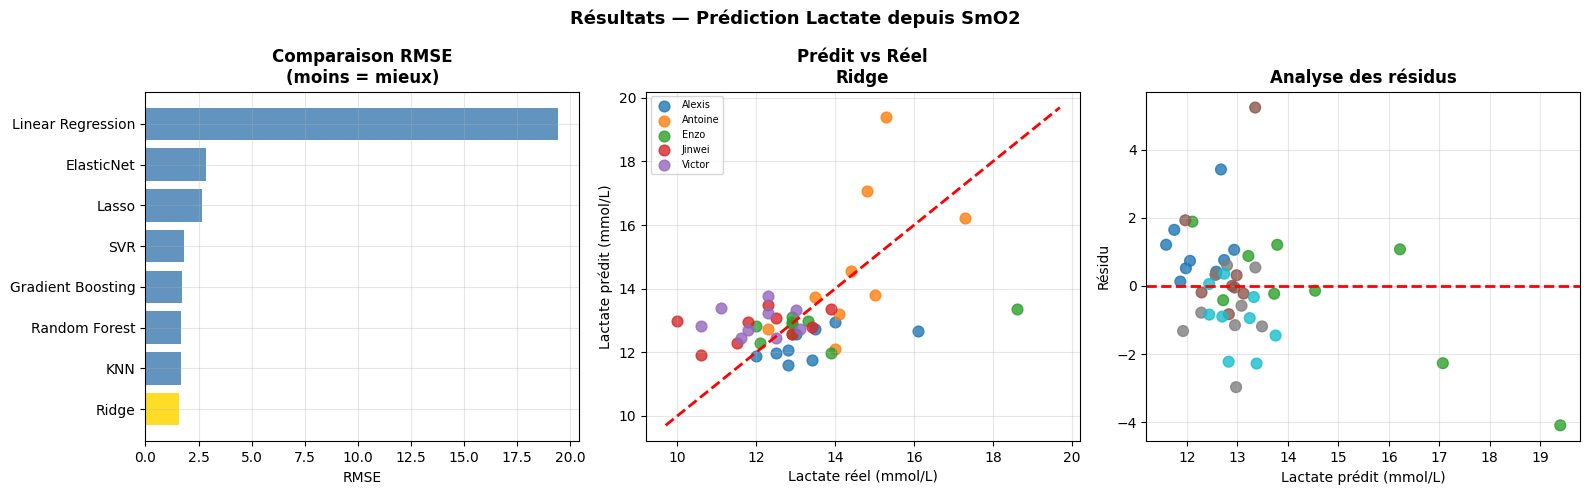

In [18]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 📦 Préparation des données
# ─────────────────────────────────────────────

feature_cols = [c for c in df_features.columns 
                if c not in ['subject', 'time_min', 'lactate']]

y      = df_features['lactate'].values
y      = np.nan_to_num(y, nan=np.nanmedian(y))
groups = df_features['subject'].values

# ─────────────────────────────────────────────
# 1️⃣ Suppression des features trop corrélées
# ─────────────────────────────────────────────

X_all        = df_features[feature_cols].values
corr_matrix  = pd.DataFrame(X_all, columns=feature_cols).corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop      = [col for col in upper.columns if any(upper[col] > 0.90)]
feature_cols_clean = [f for f in feature_cols if f not in to_drop]

print(f"🗑️  Features supprimées ({len(to_drop)}) : {to_drop}")
print(f"✅  Features conservées ({len(feature_cols_clean)}) : {feature_cols_clean}")

# ─────────────────────────────────────────────
# 2️⃣ Ajout de time_min comme feature explicite
# ─────────────────────────────────────────────

df_features['time_min_feat'] = df_features['time_min']
df_features['time_min_sq']   = df_features['time_min'] ** 2

feature_cols_final = feature_cols_clean + ['time_min_feat', 'time_min_sq']

# ✅ X final propre
X = df_features[feature_cols_final].values
X = np.nan_to_num(X, nan=0.0)  # Sécurité NaN

print(f"\n📊 X shape final : {X.shape}")
print(f"🎯 y shape       : {y.shape}")
print(f"👥 Sujets        : {np.unique(groups)}")

# ─────────────────────────────────────────────
# 3️⃣ Définition des modèles
# ─────────────────────────────────────────────

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Lasso(alpha=0.01))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  ElasticNet(alpha=0.01, l1_ratio=0.3))
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  SVR(kernel='rbf', C=10.0, epsilon=0.05, gamma='scale'))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsRegressor(n_neighbors=3))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(
            n_estimators=200, max_depth=4,
            min_samples_leaf=3, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingRegressor(
            n_estimators=100, max_depth=3,
            learning_rate=0.05, subsample=0.8, random_state=42))
    ]),
}

# ─────────────────────────────────────────────
# 4️⃣ Entraînement LOSO
# ─────────────────────────────────────────────

logo    = LeaveOneGroupOut()
results = {}

print(f"\n{'Modèle':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("─" * 55)

for name, pipeline in models.items():

    y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=logo)

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)

    results[name] = {'y_pred': y_pred, 'rmse': rmse, 'mae': mae, 'r2': r2}

    print(f"{name:<25} {rmse:>8.3f} {mae:>8.3f} {r2:>8.3f}")

# ─────────────────────────────────────────────
# 5️⃣ Meilleur modèle + Analyse par sujet
# ─────────────────────────────────────────────

best_name  = min(results, key=lambda x: results[x]['rmse'])
best_pred  = results[best_name]['y_pred']

print(f"\n🏆 Meilleur modèle : {best_name}")
print(f"   RMSE={results[best_name]['rmse']:.3f} | "
      f"MAE={results[best_name]['mae']:.3f} | "
      f"R²={results[best_name]['r2']:.3f}")

print(f"\n📊 Performance par sujet — {best_name}")
print(f"{'Sujet':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'N':>5}")
print("─" * 50)

for subject in np.unique(groups):
    mask   = groups == subject
    rmse_s = np.sqrt(mean_squared_error(y[mask], best_pred[mask]))
    mae_s  = mean_absolute_error(y[mask], best_pred[mask])
    r2_s   = r2_score(y[mask], best_pred[mask]) if mask.sum() > 1 else float('nan')
    print(f"{subject:<20} {rmse_s:>8.3f} {mae_s:>8.3f} {r2_s:>8.3f} {mask.sum():>5}")

# ─────────────────────────────────────────────
# 6️⃣ Visualisation
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Comparaison des modèles ──
ax = axes[0]
names_sorted = sorted(results, key=lambda x: results[x]['rmse'])
rmses        = [results[n]['rmse'] for n in names_sorted]
colors       = ['gold' if n == best_name else 'steelblue' for n in names_sorted]
ax.barh(names_sorted, rmses, color=colors, alpha=0.85)
ax.set_xlabel('RMSE')
ax.set_title('Comparaison RMSE\n(moins = mieux)', fontweight='bold')
ax.grid(alpha=0.3)

# ── Prédit vs Réel ──
ax = axes[1]
for subject in np.unique(groups):
    mask = groups == subject
    ax.scatter(y[mask], best_pred[mask], label=subject, alpha=0.8, s=60)
lims = [min(y.min(), best_pred.min()) - 0.3,
        max(y.max(), best_pred.max()) + 0.3]
ax.plot(lims, lims, 'r--', linewidth=2)
ax.set_xlabel('Lactate réel (mmol/L)')
ax.set_ylabel('Lactate prédit (mmol/L)')
ax.set_title(f'Prédit vs Réel\n{best_name}', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── Résidus ──
ax = axes[2]
residuals = y - best_pred
subject_idx = [list(np.unique(groups)).index(s) for s in groups]
ax.scatter(best_pred, residuals, c=subject_idx, cmap='tab10', alpha=0.8, s=60)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Lactate prédit (mmol/L)')
ax.set_ylabel('Résidu')
ax.set_title('Analyse des résidus', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Résultats — Prédiction Lactate depuis SmO2', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# Visualisation des performances
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = list(results.keys())
rmse_vals   = [results[m]['rmse'] for m in model_names]
mae_vals    = [results[m]['mae']  for m in model_names]
r2_vals     = [results[m]['r2']   for m in model_names]

# ── RMSE ──
colors = ['green' if v == min(rmse_vals) else 'steelblue' for v in rmse_vals]
axes[0].barh(model_names, rmse_vals, color=colors, alpha=0.8)
axes[0].set_title('RMSE (↓ meilleur)', fontweight='bold')
axes[0].set_xlabel('RMSE (mmol/L)')
axes[0].axvline(x=min(rmse_vals), color='green', linestyle='--', alpha=0.5)
axes[0].grid(alpha=0.3)

# ── MAE ──
colors = ['green' if v == min(mae_vals) else 'steelblue' for v in mae_vals]
axes[1].barh(model_names, mae_vals, color=colors, alpha=0.8)
axes[1].set_title('MAE (↓ meilleur)', fontweight='bold')
axes[1].set_xlabel('MAE (mmol/L)')
axes[1].axvline(x=min(mae_vals), color='green', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3)

# ── R² ──
colors = ['green' if v == max(r2_vals) else 'steelblue' for v in r2_vals]
axes[2].barh(model_names, r2_vals, color=colors, alpha=0.8)
axes[2].set_title('R² (↑ meilleur)', fontweight='bold')
axes[2].set_xlabel('R²')
axes[2].axvline(x=max(r2_vals), color='green', linestyle='--', alpha=0.5)
axes[2].grid(alpha=0.3)

plt.suptitle('Comparaison des modèles — LOSO Cross-Validation', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# Scatter : Prédit vs Réel (meilleur modèle)
# ─────────────────────────────────────────────

best_model = min(results, key=lambda x: results[x]['rmse'])
print(f"\n🏆 Meilleur modèle : {best_model}")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    
    # Scatter par sujet
    for subject in np.unique(groups):
        mask = groups == subject
        ax.scatter(y[mask], res['y_pred'][mask], label=subject, alpha=0.8, s=40)
    
    # Ligne parfaite
    lims = [min(y.min(), res['y_pred'].min()), 
            max(y.max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
    
    ax.set_xlabel('Lactate réel (mmol/L)')
    ax.set_ylabel('Lactate prédit (mmol/L)')
    ax.set_title(f'{name}\nRMSE={res["rmse"]:.2f} | R²={res["r2"]:.2f}',
                 fontweight='bold' if name == best_model else 'normal',
                 color='green' if name == best_model else 'black')
    ax.legend(fontsize=6)
    ax.grid(alpha=0.3)

plt.suptitle('Prédit vs Réel — Tous les modèles (LOSO)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# Feature Importance (Random Forest)
# ─────────────────────────────────────────────

# Entraînement sur toutes les données
rf_pipeline = models['Random Forest']
rf_pipeline.fit(X, y)

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['green' if v > feat_imp['importance'].quantile(0.75) 
          else 'steelblue' for v in feat_imp['importance']]
plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors, alpha=0.8)
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance')
plt.axvline(x=feat_imp['importance'].quantile(0.75), 
            color='green', linestyle='--', alpha=0.5, label='Top 25%')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Top 5 features
print("\n🔝 Top 5 features :")
print(feat_imp.tail(5)[['feature', 'importance']].iloc[::-1].to_string(index=False))
